# 03 - Regional Crime Pattern Analysis (Clustering)
**Owners:** Eglen & Teddy  |  **Dataset:** `data/USArrests.csv`  |  **Branch:** `feature/arrests-clustering`

Goal: find clusters of US states via K-Means and GMM with PCA.




## Rubric checklist
- [ ] Standardize the dataset
- [ ] Select the top 3 relevant features
- [ ] Apply PCA to reduce to 2 principal components
- [ ] Use the elbow method (inertia) to pick k for K-Means
- [ ] Use BIC to pick the number of components for GMM
- [ ] Fit K-Means (hard assignment) and GMM (probabilistic)
- [ ] Visualize and compare the two clustering results
- [ ] Interpret the clusters


In [4]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest,f_classif


## Understanding the data

In [5]:
# Load data
df = pd.read_csv("../data/USArrests.csv")

In [9]:
df.head(5)

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [10]:
df.shape

(50, 5)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [15]:
df.isna().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


Separate state from clustering variables since it could distort clustering

In [18]:
# Separate state names from numerical clustering features
state_names = df["State"]
features = df.drop(columns=["State"])

print("Clustering features:")
print(features.columns.tolist())

Clustering features:
['Murder', 'Assault', 'UrbanPop', 'Rape']


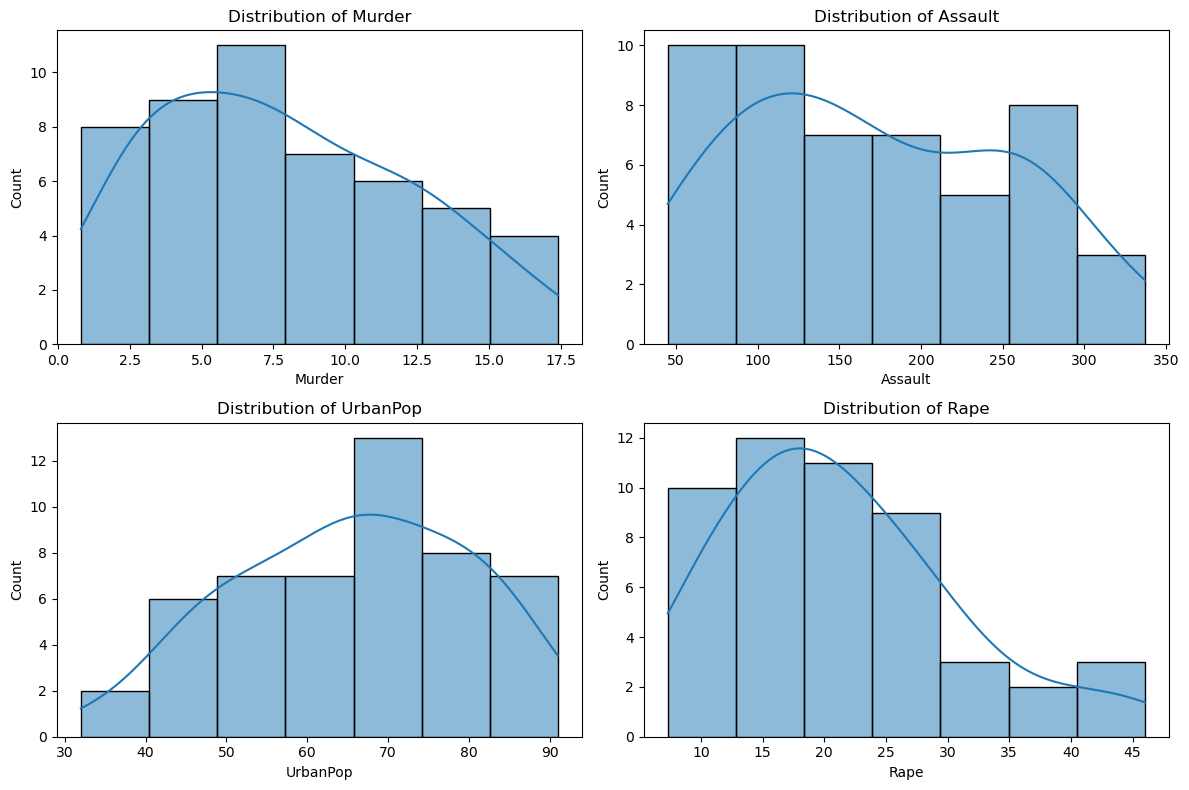

In [21]:
# numerical features distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), features.columns):
    sns.histplot(data=features,x=column,kde=True,ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

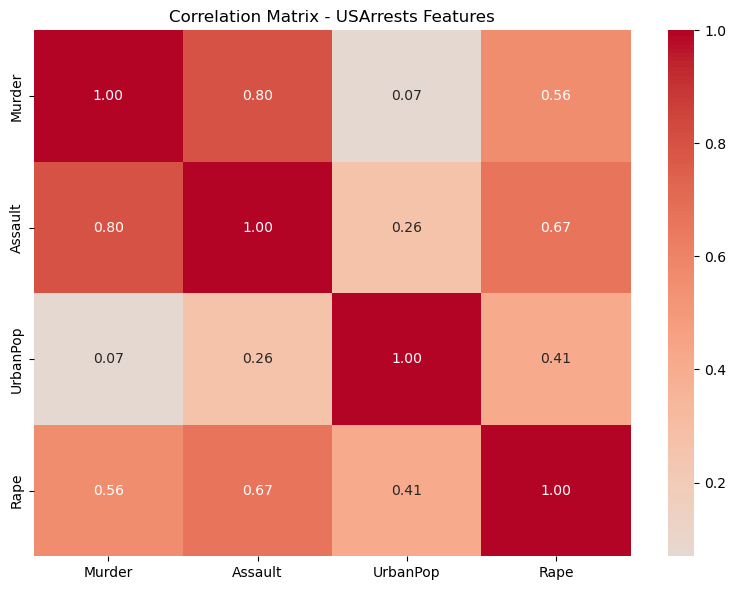

In [22]:
# Correlation between numerical features
correlation_matrix = features.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - USArrests Features")
plt.tight_layout()
plt.show()

## Standardize the numerical features

In [23]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=features.index
)

features_scaled.head()

,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


Standardization puts the variables onto a comparable scale. Example, if we used the raw values, Assault could have a much larger influence on distance calculations simply because its numerical values are larger.

After standardization, each feature has approximately mean=0 and sd=1

In [24]:
# Checking if standardization worked
print("Means after standardization:")
print(features_scaled.mean())

print("\nStandard deviations after standardization:")
print(features_scaled.std())

Means after standardization:
Murder     -7.105427e-17
Assault     1.387779e-16
UrbanPop   -4.396483e-16
Rape        8.593126e-16
dtype: float64

Standard deviations after standardization:
Murder      1.010153
Assault     1.010153
UrbanPop    1.010153
Rape        1.010153
dtype: float64


Worked because the means are very small numbers (closer to zero) and all sd close to 1

## Feature Selection (Top 3)

For this dataset, we would initially investigate the crime variables using their relationships with one another (using the correlation matrix above). But, UrbanPop is not a crime-rate variable as it describes the population living in urbern areas, while Murder, Assault, and Rape directly measure crime. 

Therefore, a sensible selection would be Murder, Assault, and Rape, since the clustering is based specifically on crime patterns rather than population structure

In [ ]:
# Select the three crime-rate features
top_features = [
    "Murder",
    "Assault",
    "Rape"
]

features_top3 = features_scaled[top_features]

print("Selected features:")
print(top_features)

features_top3.head()

Selected features:
['Murder', 'Assault', 'Rape']


,Murder,Assault,Rape
0,1.255179,0.790787,-0.003451
1,0.513019,1.118060,2.509424
2,0.072361,1.493817,1.053466
3,0.234708,0.233212,-0.186794
4,0.281093,1.275635,2.088814


## Modeling

PCA

In [26]:
# Apply PCA and reduce to 2 principal components
pca = PCA(n_components=2)

features_pca = pca.fit_transform(features_top3)

pca_df = pd.DataFrame(
    features_pca,
    columns=["PC1", "PC2"],
    index=features_top3.index
)

pca_df.head()

,PC1,PC2
0,1.210191,-0.842277
1,2.332187,1.539434
2,1.518593,0.503363
3,0.177776,-0.328029
4,2.066000,1.285497


In [27]:
# Explained variance of the principal components
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explains {explained_variance[0]:.2%} of the variance.")
print(f"PC2 explains {explained_variance[1]:.2%} of the variance.")
print(f"Together, PC1 and PC2 explain {explained_variance.sum():.2%} of the variance.")

PC1 explains 78.62% of the variance.
PC2 explains 15.27% of the variance.
Together, PC1 and PC2 explain 93.89% of the variance.


The two principal components retain 93.89% of the variation in the original three features. That's a good reduction

In [28]:
# PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=top_features
)

loadings

,PC1,PC2
Murder,0.582601,-0.533953
Assault,0.607982,-0.214024
Rape,0.539384,0.817978


PC1: All three are positive and relatively similar in magnitude, which means PC1 is strongly influenced by all three crime variables in the same direction.

So we can reasonably interpret PC1 as an indicator of overall crime intensity. States with higher PC1 values tend to have relatively higher levels across the three crime measures.This also explains why PC1 captures such a large 78.62% of the variance.

PC2: Rape has a strong positive loading, while Murder has a substantial negative loading and Assault has a smaller negative loading. PC2 appears to distinguish states based more on the relative pattern of rape versus murder/assault rates. Therefore we would say, PC2 appears to distinguish states based more on the relative pattern of rape versus murder/assault rates.

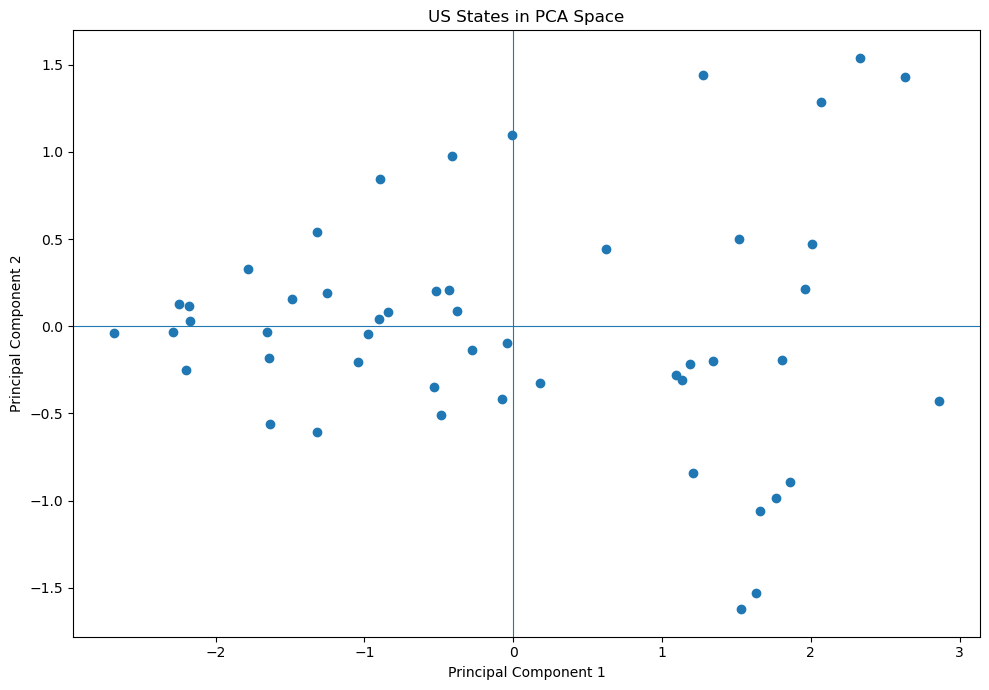

In [29]:
# Visualize the PCA-transformed data
plt.figure(figsize=(10, 7))

plt.scatter(pca_df["PC1"],pca_df["PC2"])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("US States in PCA Space")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

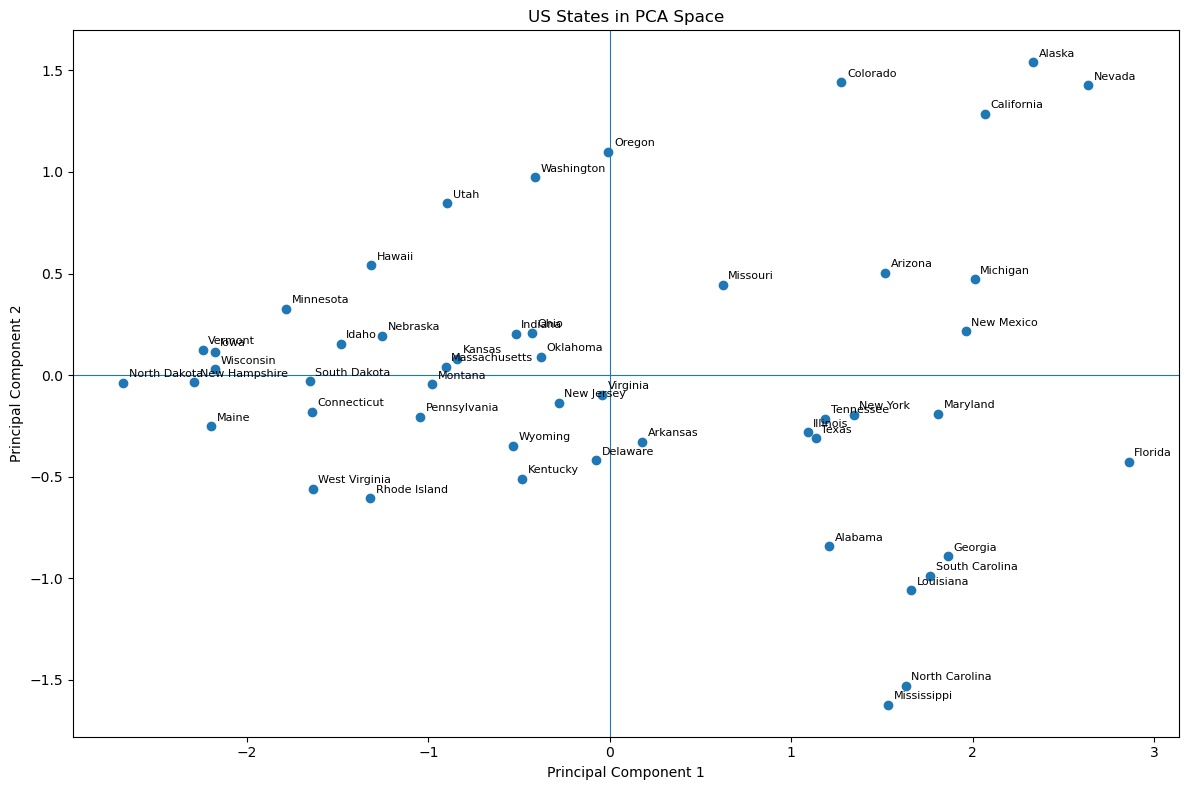

In [ ]:
# PCA plot with state labels - to identofy which states are closer together
plt.figure(figsize=(12, 8))

plt.scatter(pca_df["PC1"],pca_df["PC2"])

for i, state in enumerate(state_names):
    plt.annotate(
        state,
        (pca_df.iloc[i]["PC1"], pca_df.iloc[i]["PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("US States in PCA Space")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

Right side (PC1 axis) generally indicates greater overral crime intensity. Vertically (PC2) the states on the top region tend to have relatively stronger rape-related patterns compared with murder/assault, while states lower on PC2 show the opposite pattern.

Note: These aren't cluters yet

## K-Means
Finding best number of clusters

In [ ]:
# Calculate K-Means inertia for different numbers of clusters

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(pca_df)
    inertia_values.append(kmeans.inertia_)

print("Inertia values:")
for k, inertia in zip(k_values, inertia_values):
    print(f"k={k}: {inertia:.2f}")

c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Inertia values:
k=2: 47.12
k=3: 32.87
k=4: 19.51
k=5: 15.88
k=6: 13.40
k=7: 10.48
k=8: 8.99
k=9: 7.15
k=10: 6.30


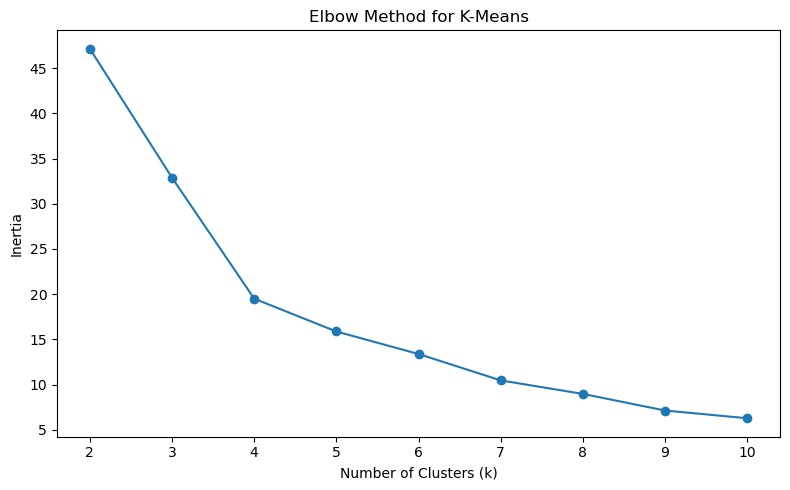

In [34]:
# Elbow method for selecting k

plt.figure(figsize=(8, 5))

plt.plot(k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

K=4

From 2 → 3 and 3 → 4, inertia drops substantially. After k = 4, the improvements become much smaller

In [35]:
# Fit the final K-Means model using the selected number of clusters

best_k = 4
kmeans_final = KMeans(n_clusters=best_k,random_state=42,n_init=10)

kmeans_labels = kmeans_final.fit_predict(pca_df)

print(f"Selected number of clusters: {best_k}")

Selected number of clusters: 4


c:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
# Add K-Means cluster assignments

kmeans_results = pca_df.copy()

kmeans_results["KMeans_Cluster"] = kmeans_labels
kmeans_results["State"] = state_names.values

kmeans_results.head()

,PC1,PC2,KMeans_Cluster,State
0,1.210191,-0.842277,1,Alabama
1,2.332187,1.539434,2,Alaska
2,1.518593,0.503363,2,Arizona
3,0.177776,-0.328029,3,Arkansas
4,2.066000,1.285497,2,California


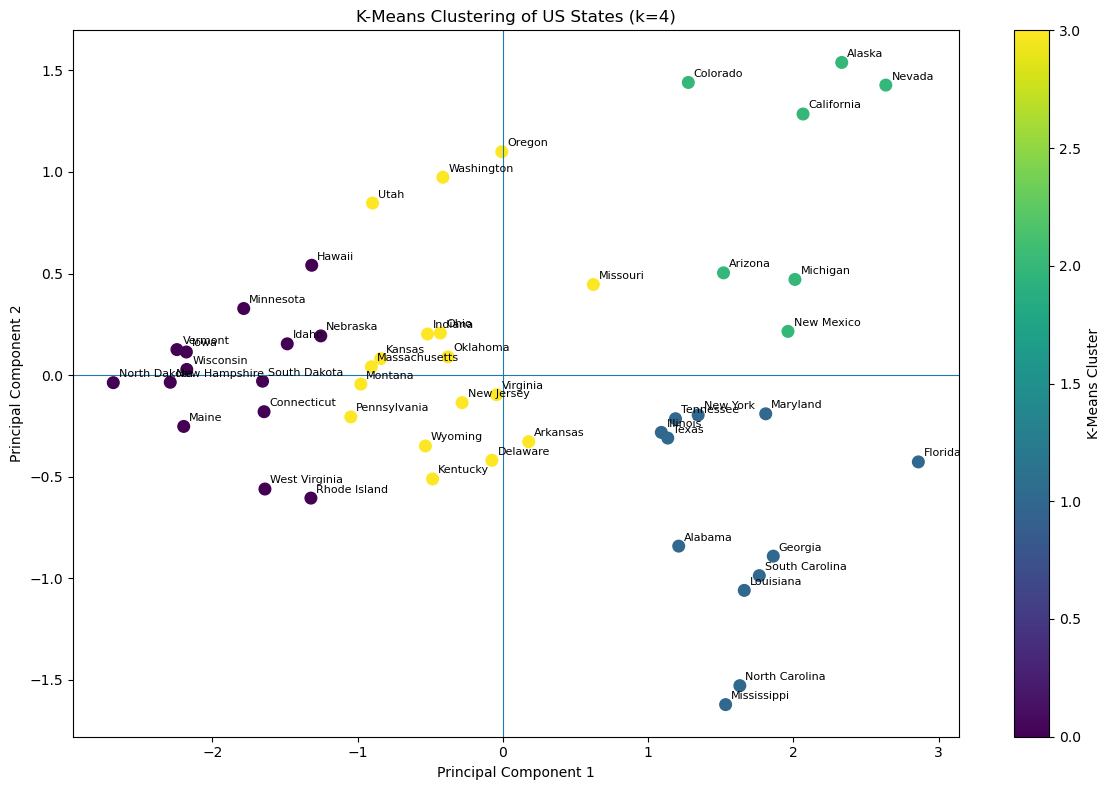

In [37]:
# Visualize K-Means clusters

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    kmeans_results["PC1"],
    kmeans_results["PC2"],
    c=kmeans_results["KMeans_Cluster"],
    cmap="viridis",
    s=70
)

# Add state labels
for i, state in enumerate(kmeans_results["State"]):
    plt.annotate(
        state,
        (
            kmeans_results.iloc[i]["PC1"],
            kmeans_results.iloc[i]["PC2"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of US States (k=4)")

plt.colorbar(
    scatter,
    label="K-Means Cluster"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

See distinctively which cluster each state belongs to

In [38]:
# List states in each K-Means cluster
cluster_members = (
    kmeans_results
    .sort_values("KMeans_Cluster")
    [["State", "PC1", "PC2", "KMeans_Cluster"]]
)

cluster_members

,State,PC1,PC2,KMeans_Cluster
18,Maine,-2.196670,-0.252887,0
22,Minnesota,-1.783642,0.327694,0
44,Vermont,-2.243305,0.125468,0
14,Iowa,-2.178532,0.113536,0
48,Wisconsin,-2.175679,0.027674,0
11,Idaho,-1.484140,0.153802,0
10,Hawaii,-1.315626,0.540721,0
38,Rhode Island,-1.321307,-0.605841,0
26,Nebraska,-1.253292,0.192876,0
40,South Dakota,-1.653999,-0.030104,0


In [39]:
# Display states grouped by K-Means cluster
for cluster in sorted(kmeans_results["KMeans_Cluster"].unique()):
    states = kmeans_results.loc[
        kmeans_results["KMeans_Cluster"] == cluster,
        "State"
    ].tolist()
    
    print(f"\nCluster {cluster}:")
    print(", ".join(states))


Cluster 0:
Connecticut, Hawaii, Idaho, Iowa, Maine, Minnesota, Nebraska, New Hampshire, North Dakota, Rhode Island, South Dakota, Vermont, West Virginia, Wisconsin

Cluster 1:
Alabama, Florida, Georgia, Illinois, Louisiana, Maryland, Mississippi, New York, North Carolina, South Carolina, Tennessee, Texas

Cluster 2:
Alaska, Arizona, California, Colorado, Michigan, Nevada, New Mexico

Cluster 3:
Arkansas, Delaware, Indiana, Kansas, Kentucky, Massachusetts, Missouri, Montana, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Utah, Virginia, Washington, Wyoming


In [40]:
# Count observations in each K-Means cluster
cluster_sizes = (
    kmeans_results["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

KMeans_Cluster
0    14
1    12
2     7
3    17
Name: count, dtype: int64

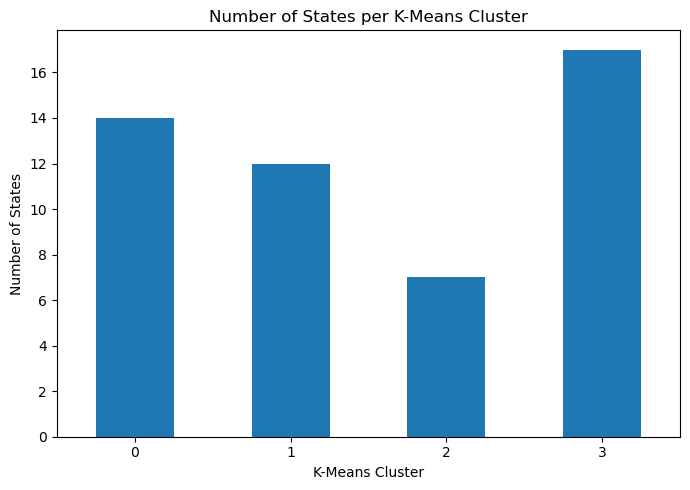

In [42]:
# Bar plot visual for K-Means cluster sizes
plt.figure(figsize=(7, 5))

cluster_sizes.plot(kind="bar")

plt.xlabel("K-Means Cluster")
plt.ylabel("Number of States")
plt.title("Number of States per K-Means Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()